# Thesis - Intelligent Reflecting Surface

## Import

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time 

## Scenario

This cell visualizes the 3D indoor scenario, including room boundaries, BS and IRS positions, and the UE area.

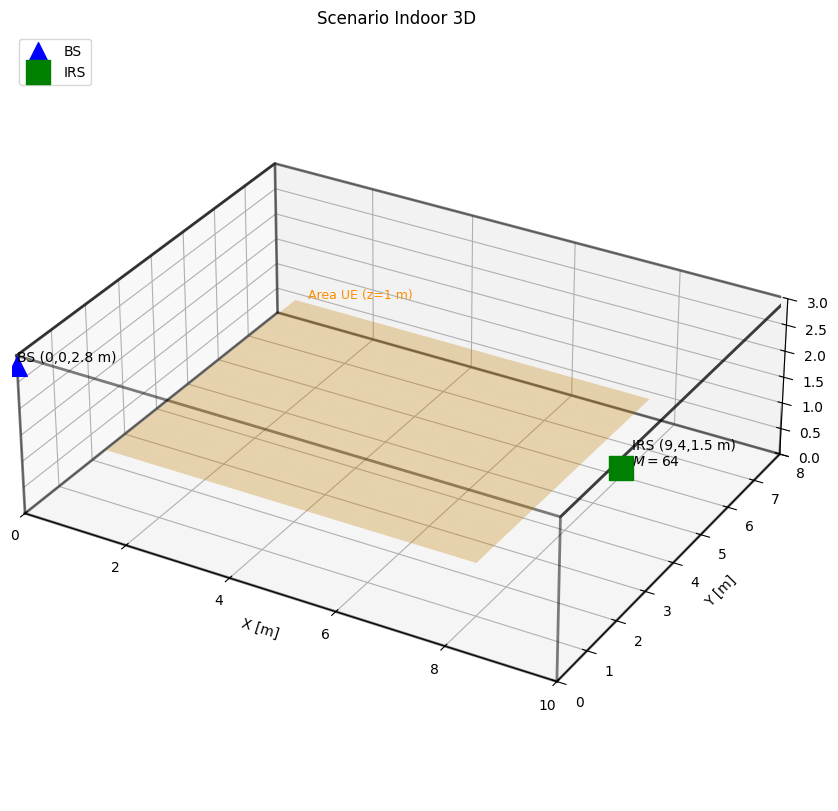

In [2]:
fig = plt.figure(figsize=(10, 8), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")

ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.set_zlim(0, 3)
ax.set_box_aspect((10, 8, 3))

x_walls = [0, 10, 10, 0, 0]
y_walls = [0, 0, 8, 8, 0]
z_walls = [0, 0, 0, 0, 0]
ax.plot(x_walls, y_walls, z_walls, "k-", lw=2, alpha=0.5)
ax.plot(x_walls, y_walls, [3] * 5, "k-", lw=2, alpha=0.5)
ax.plot([0] * 4, [0, 0, 8, 8], [0, 3, 3, 0], "k-", lw=2, alpha=0.5)
ax.plot([10] * 4, [0, 0, 8, 8], [0, 3, 3, 0], "k-", lw=2, alpha=0.5)

# BS blu (0,0,2.8)
ax.scatter(0, 0, 2.8, c="blue", s=200, marker="^", label="BS")
ax.text(0, 0, 2.9, "BS (0,0,2.8 m)", fontsize=10)

# IRS verde (9,4,1.5), quadrato 8x8 approx
ax.scatter(9, 4, 1.5, c="green", s=300, marker="s", label="IRS")
ax.text(9.2, 4, 1.6, "IRS (9,4,1.5 m)\n$M=64$", fontsize=10)

# Area UE arancione [1,8]x[1,7] z=1
xx, yy = np.meshgrid(np.linspace(1, 8, 10), np.linspace(1, 7, 10))
ax.plot_surface(xx, yy, np.ones_like(xx), alpha=0.3, color="orange")
ax.text(1.2, 7.1, 1.05, "Area UE (z=1 m)", color="darkorange", fontsize=9)

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_zlabel("Z [m]", labelpad=12)
ax.set_title("Scenario Indoor 3D")
ax.legend(loc="upper left")

plt.show()

## Dataset Generation

This section creates a synthetic dataset for Intelligent Reflecting Surface (IRS) learning.

For each user position $\mathbf{p}=[x,y]^T$, the simplified cascaded channel follows the notation used in the thesis:
$$
h_{\mathrm{eff}}(\mathbf{p},\boldsymbol{\theta})=\mathbf{h}_{\mathrm{IU}}^{H}(\mathbf{p})\,\mathrm{diag}(e^{j\boldsymbol{\theta}})\,\mathbf{h}_{\mathrm{BI}}
$$
where $\boldsymbol{\theta}=[\theta_1,\dots,\theta_M]^T$ is the IRS phase vector.
The element-wise phase-alignment rule is:
$$
\theta_m^{\star}(\mathbf{p})=-\angle\!\left(h_{\mathrm{IU},m}^{*}(\mathbf{p})\,h_{\mathrm{BI},m}\right),\quad m=1,\dots,M
$$
With $K$ quantized levels, phases are projected onto:
$$
\theta_m \in \left\{0,\frac{2\pi}{K},\dots,\frac{2\pi(K-1)}{K}\right\}
$$
Thus each training sample is a pair $(\mathbf{p}^{(i)},\boldsymbol{\theta}^{\star(i)})$.

In [3]:
def dataset(samples=1000, size=8, K=4):
    """
    Generate synthetic UE positions and brute-force IRS phase labels.

    Args:
        samples: Number of dataset samples (UE positions).
        size: IRS side length. Total IRS elements are M = size**2.
        K: Number of quantized phase levels used in the search grid.

    Returns:
        positions: Array with shape (samples, 2) containing UE coordinates (x, y).
        theta_opt: Array with shape (samples, M) containing the best phase profile found
            for each sample according to the simplified received-power metric.
    """

    # IRS element positions on a 2D grid, with fixed height z = 1.5
    xx, yy = np.meshgrid(np.linspace(8.5, 9.5, size), np.linspace(3.5, 4.5, size), indexing="ij")
    irs_pos = np.column_stack((xx.ravel(), yy.ravel(), np.full(xx.size, 1.5)))
    # Random UE positions in the area: x in [1, 8], y in [1, 7]
    positions = np.hstack((np.random.uniform(1, 8, (samples, 1)), np.random.uniform(1, 7, (samples, 1))))
    # IRS total number of reflecting elements
    M = size**2

    phase_levels = np.linspace(0, 2 * np.pi, K, endpoint=False)
    theta_opt = np.zeros((samples, M))
    for i in range(samples):
        p = np.array([positions[i, 0], positions[i, 1], 1.0]) # UE with z = 1

        # Simplified channels: pathloss approximation + random phase
        h_BI = 10**(-3.5 / 10) * np.exp(1j * np.random.uniform(0,2 * np.pi, M)) # BS-IRS, 3.5 dB
        h_IU = np.exp(-np.linalg.norm(irs_pos - p, axis=1) / 10) * np.exp(1j * np.random.uniform(0, 2 * np.pi, M))  # IRS-UE

        g = h_IU.conj() * h_BI # channel product
        theta = -np.angle(g) # optimal continuous phase
        idx = np.argmin(np.abs(theta[:,None] - phase_levels), axis=1) # quantization (K phase levels)

        theta_opt[i] = phase_levels[idx]

    return positions, theta_opt

## Algorithm

Helper functions used across all algorithms.

The train/test split is defined as
$$
\mathcal{D}_{\mathrm{train}}=\{(\mathbf{x}^{(i)},\boldsymbol{\theta}^{\star(i)})\}_{i=1}^{N_{\mathrm{tr}}},\quad
\mathcal{D}_{\mathrm{test}}=\{(\mathbf{x}^{(i)},\boldsymbol{\theta}^{\star(i)})\}_{i=N_{\mathrm{tr}}+1}^{N},\quad N_{\mathrm{tr}}=\lfloor rN\rfloor
$$
with split ratio $r\in(0,1)$.
The error metric follows the thesis notation:
$$
\mathrm{NMSE}=\frac{\sum_{i=1}^{N}\lVert \boldsymbol{\theta}^{\star(i)}-\hat{\boldsymbol{\theta}}^{(i)} \rVert_2^2}{\sum_{i=1}^{N}\lVert \boldsymbol{\theta}^{\star(i)} \rVert_2^2},
$$
where the common factor $1/N$ in numerator and denominator is canceled.

In [4]:
def train_test_split(positions, theta, train_ratio=0.8):
    split = int(train_ratio * len(positions))
    return (positions[:split], positions[split:], theta[:split], theta[split:])  # pos_train, pos_test, theta_train, theta_test

def nmse(theta_true, theta_pred):
    return np.mean((theta_true - theta_pred) ** 2) / np.mean(theta_true ** 2)  # mse / power

### Multivariate Linear Regression

Input and output:
$$
\mathbf{x}=[x,y]^T \in \mathbb{R}^2, \qquad \hat{\boldsymbol{\theta}} \in \mathbb{R}^{M}.
$$

The model is linear:
$$
\hat{\boldsymbol{\theta}} = \mathbf{W}\mathbf{x}+\mathbf{b}.
$$

In practice, $\mathbf{W}$ and $\mathbf{b}$ are estimated with least squares on the training set.
Then each predicted phase is projected to the nearest hardware level:
$$
\theta_m \leftarrow \arg\min_{q\in\{0,\frac{2\pi}{K},\dots,\frac{2\pi(K-1)}{K}\}} |\hat{\theta}_m-q|, \quad m=1,\dots,M.
$$

Intuition: this is the fastest baseline, but it can miss nonlinear relations between position and optimal phase profile.

In [5]:
def lg(pos_train, pos_test, theta_train, theta_test):
    X = np.concatenate([pos_train, np.ones((pos_train.shape[0], 1))], axis=1)  # Add bias term as an extra column of ones
    theta_ls = np.linalg.pinv(X.T @ X) @ X.T @ theta_train  # Closed-form least-squares solution

    W, b = theta_ls[:-1], theta_ls[-1]
    theta_pred = pos_test @ W + b

    return theta_pred, nmse(theta_test, theta_pred)

### k-Nearest Neighbors (kNN) Regression

kNN does not learn explicit parameters. It stores training samples and predicts from the most similar positions.

Given a query position $\mathbf{x}$, the algorithm:
1. Computes distances from all training positions.
2. Selects the $k$ nearest neighbors.
3. Averages their phase vectors (optionally with distance-based weights).

A common weighted form is:
$$
\hat{\boldsymbol{\theta}}(\mathbf{x})=\sum_{j\in\mathcal{N}_k(\mathbf{x})} w_j\,\boldsymbol{\theta}^{\star(j)},
$$
with larger weights for closer neighbors.

Finally, $\hat{\boldsymbol{\theta}}$ is quantized to the same $K$ IRS phase levels.

Intuition: kNN can model nonlinear behavior well, but prediction becomes heavier when the training set grows.

In [6]:
def knn(pos_train, pos_test, theta_train, theta_test, k=5):
    dists = np.linalg.norm(pos_test[:, None, :] - pos_train[None, :, :], axis=2)  # pairwise distances (N_test x N_train)
    idx = np.argsort(dists, axis=1)[:, :k]  # indices of k nearest neighbors

    neighbors_d = np.take_along_axis(dists, idx, axis=1) + 1e-8  # k nearest distances
    neighbors_theta = theta_train[idx]  # corresponding theta values

    weights = 1 / neighbors_d
    weights = weights / weights.sum(axis=1, keepdims=True)

    theta_pred = np.sum(neighbors_theta * weights[:, :, None], axis=1)  # weighted average

    return theta_pred, nmse(theta_test, theta_pred)

### Multi-Layer Perceptron

This approach uses a Multi-Layer Perceptron (MLP) to learn a nonlinear mapping from position to IRS phase vector.

Input/output are the same as before:
$$
\mathbf{x}=[x,y]^T \in \mathbb{R}^2, \qquad \hat{\boldsymbol{\theta}}\in\mathbb{R}^{M}.
$$

Key steps:
1. Standardize input positions and target phases using training-set statistics.
2. Use a feed-forward network with two hidden ReLU layers and one linear output layer.
3. Train with mini-batch gradient descent to minimize mean-squared error.
4. Map predictions back to the original scale, then evaluate with NMSE.

Intuition: MLP is more flexible than linear regression and can capture complex patterns, but it needs more training time and hyperparameter tuning.

In [7]:
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def mlp(pos_train, pos_test, theta_train, theta_test, hidden=(64, 32), lr=1e-3, epochs=100, batch_size=32, seed=42, verbose=True, print_every=20):
    """Train a simple two-hidden-layer MLP for multi-output regression."""
    pos_train = np.asarray(pos_train, dtype=float)
    pos_test = np.asarray(pos_test, dtype=float)
    theta_train = np.asarray(theta_train, dtype=float)
    theta_test = np.asarray(theta_test, dtype=float)

    h1, h2 = hidden
    input_dim = pos_train.shape[1]
    output_dim = theta_train.shape[1]

    rng = np.random.default_rng(seed)

    # Standardize inputs and targets using only the training split.
    pos_mean = pos_train.mean(axis=0, keepdims=True)
    pos_std = pos_train.std(axis=0, keepdims=True)
    pos_std[pos_std == 0] = 1.0

    theta_mean = theta_train.mean(axis=0, keepdims=True)
    theta_std = theta_train.std(axis=0, keepdims=True)
    theta_std[theta_std == 0] = 1.0

    pos_train_scaled = (pos_train - pos_mean) / pos_std
    pos_test_scaled = (pos_test - pos_mean) / pos_std
    theta_train_scaled = (theta_train - theta_mean) / theta_std

    # He initialization works well with ReLU activations.
    W1 = rng.standard_normal((input_dim, h1)) * np.sqrt(2.0 / input_dim)
    b1 = np.zeros((1, h1))
    W2 = rng.standard_normal((h1, h2)) * np.sqrt(2.0 / h1)
    b2 = np.zeros((1, h2))
    W3 = rng.standard_normal((h2, output_dim)) * np.sqrt(1.0 / h2)
    b3 = np.zeros((1, output_dim))

    sample_count = pos_train_scaled.shape[0]

    for epoch in range(epochs):
        permutation = rng.permutation(sample_count)
        epoch_loss = 0.0

        for start in range(0, sample_count, batch_size):
            stop = start + batch_size
            batch_idx = permutation[start:stop]

            pos_batch = pos_train_scaled[batch_idx]
            theta_batch = theta_train_scaled[batch_idx]

            z1 = pos_batch @ W1 + b1
            a1 = relu(z1)
            z2 = a1 @ W2 + b2
            a2 = relu(z2)
            theta_pred_batch = a2 @ W3 + b3

            batch_loss = np.mean((theta_pred_batch - theta_batch) ** 2)
            epoch_loss += batch_loss * pos_batch.shape[0]

            dL = 2.0 * (theta_pred_batch - theta_batch) / pos_batch.shape[0]
            dW3 = a2.T @ dL
            db3 = np.sum(dL, axis=0, keepdims=True)

            da2 = dL @ W3.T
            dz2 = da2 * relu_deriv(z2)
            dW2 = a1.T @ dz2
            db2 = np.sum(dz2, axis=0, keepdims=True)

            da1 = dz2 @ W2.T
            dz1 = da1 * relu_deriv(z1)
            dW1 = pos_batch.T @ dz1
            db1 = np.sum(dz1, axis=0, keepdims=True)

            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2
            W3 -= lr * dW3
            b3 -= lr * db3

        if verbose and (epoch == 0 or (epoch + 1) % print_every == 0):
            mean_epoch_loss = epoch_loss / sample_count
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {mean_epoch_loss:.6f}")

    a1_test = relu(pos_test_scaled @ W1 + b1)
    a2_test = relu(a1_test @ W2 + b2)
    theta_pred_scaled = a2_test @ W3 + b3
    theta_pred = theta_pred_scaled * theta_std + theta_mean

    return theta_pred, nmse(theta_test, theta_pred)

# Comparison

Linear | NMSE: 0.668311 | Training Time: 0.000 s | Tracking@1: 46.02% | Tracking@2: 87.55% | Phase MAE: 56.13 deg
   kNN | NMSE: 0.837714 | Training Time: 0.041 s | Tracking@1: 45.51% | Tracking@2: 82.91% | Phase MAE: 57.19 deg
   MLP | NMSE: 0.668155 | Training Time: 0.311 s | Tracking@1: 47.07% | Tracking@2: 87.55% | Phase MAE: 56.14 deg
Baseline random Tracking@1 (K=4): 25.00%
Baseline random Tracking@2 (K=4): 50.00%


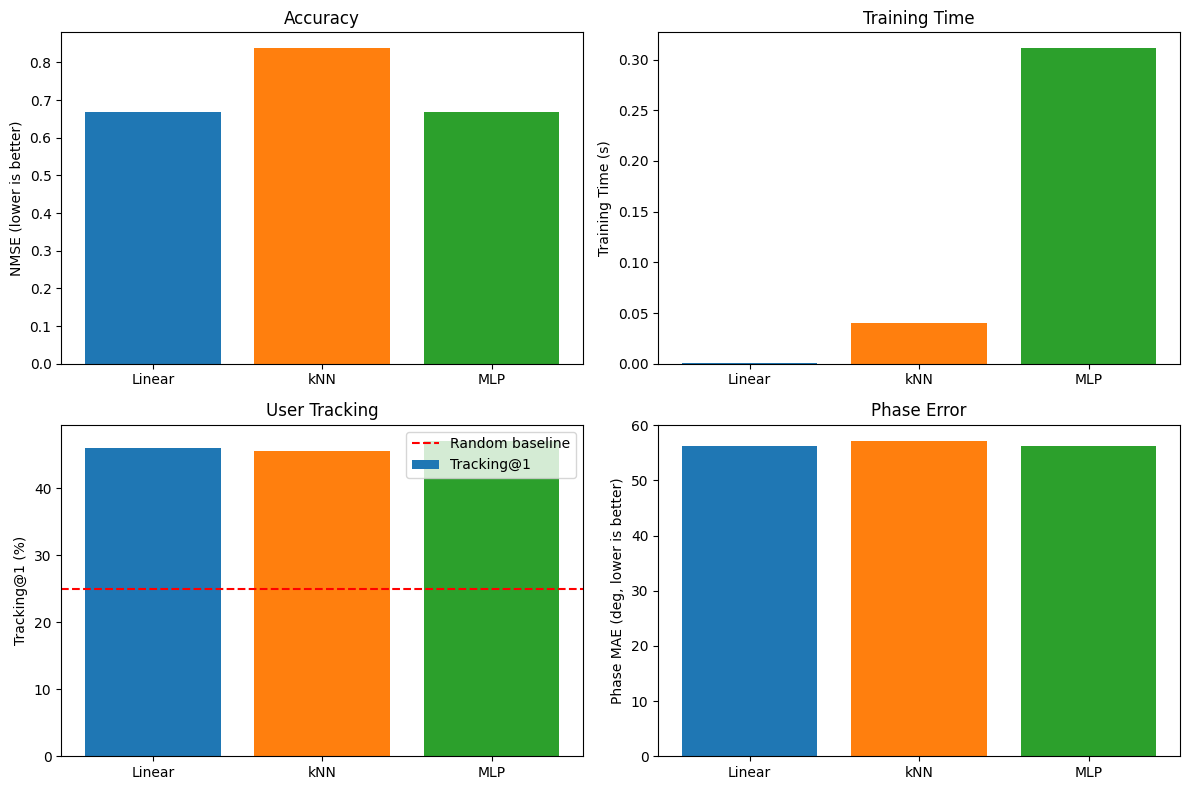

In [8]:
import time
import numpy as np
import matplotlib.pyplot as plt

# Build data from the notebook dataset generator
K = 4
X, y = dataset(samples=2000, size=8, K=K)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_ratio=0.8)

phase_levels = np.linspace(0, 2 * np.pi, K, endpoint=False)


def wrap_to_pi(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def to_phase_idx(theta, levels):
    """Map each phase to the nearest quantized level index (circular distance)."""
    theta_wrapped = np.mod(theta, 2 * np.pi)
    diff = np.abs(theta_wrapped[..., None] - levels[None, None, :])
    circular_diff = np.minimum(diff, 2 * np.pi - diff)
    return np.argmin(circular_diff, axis=-1)


def topk_tracking(y_true, y_pred, levels, k=1):
    """Fraction of elements where true quantized level is in top-k closest predicted levels."""
    y_true_idx = to_phase_idx(y_true, levels)
    y_pred_wrapped = np.mod(y_pred, 2 * np.pi)
    diff = np.abs(y_pred_wrapped[..., None] - levels[None, None, :])
    circular_diff = np.minimum(diff, 2 * np.pi - diff)
    topk_idx = np.argsort(circular_diff, axis=-1)[..., :k]
    return np.mean(np.any(topk_idx == y_true_idx[..., None], axis=-1))


models = [
    ("Linear", lambda: lg(X_train, X_test, y_train, y_test)),
    ("kNN", lambda: knn(X_train, X_test, y_train, y_test, k=5)),
    ("MLP", lambda: mlp(X_train, X_test, y_train, y_test, verbose=False)),
]

algorithms = []
nmse_scores = []
training_times = []
tracking_at1 = []
tracking_at2 = []
phase_mae_deg = []

y_true_idx = to_phase_idx(y_test, phase_levels)

for name, run_model in models:
    start = time.time()
    y_pred, score_nmse = run_model()
    elapsed_train = time.time() - start

    y_pred_idx = to_phase_idx(y_pred, phase_levels)
    trk1 = np.mean(y_pred_idx == y_true_idx)
    trk2 = topk_tracking(y_test, y_pred, phase_levels, k=min(2, K))

    phase_err = np.abs(wrap_to_pi(y_pred - y_test))
    mae_deg = np.degrees(np.mean(phase_err))

    algorithms.append(name)
    nmse_scores.append(score_nmse)
    training_times.append(elapsed_train)
    tracking_at1.append(trk1)
    tracking_at2.append(trk2)
    phase_mae_deg.append(mae_deg)

# Random-baseline references for K-level quantization
baseline_top1 = 1.0 / K
baseline_top2 = min(2.0 / K, 1.0)

# Numeric summary
for name, nmse_val, t_train, trk1, trk2, mae_d in zip(
    algorithms, nmse_scores, training_times, tracking_at1, tracking_at2, phase_mae_deg
):
    print(
        f"{name:>6} | NMSE: {nmse_val:.6f} | Training Time: {t_train:.3f} s "
        f"| Tracking@1: {trk1*100:.2f}% | Tracking@2: {trk2*100:.2f}% | Phase MAE: {mae_d:.2f} deg"
    )

print(f"Baseline random Tracking@1 (K={K}): {baseline_top1*100:.2f}%")
print(f"Baseline random Tracking@2 (K={K}): {baseline_top2*100:.2f}%")

# Comparison plots
x = np.arange(len(algorithms))
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
colors = ["tab:blue", "tab:orange", "tab:green"]

axs[0, 0].bar(x, nmse_scores, color=colors)
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(algorithms)
axs[0, 0].set_ylabel("NMSE (lower is better)")
axs[0, 0].set_title("Accuracy")

axs[0, 1].bar(x, training_times, color=colors)
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(algorithms)
axs[0, 1].set_ylabel("Training Time (s)")
axs[0, 1].set_title("Training Time")

axs[1, 0].bar(x, np.array(tracking_at1) * 100, color=colors, label="Tracking@1")
axs[1, 0].axhline(baseline_top1 * 100, color="red", linestyle="--", linewidth=1.5, label="Random baseline")
axs[1, 0].set_xticks(x)
axs[1, 0].set_xticklabels(algorithms)
axs[1, 0].set_ylabel("Tracking@1 (%)")
axs[1, 0].set_title("User Tracking")
axs[1, 0].legend()

axs[1, 1].bar(x, phase_mae_deg, color=colors)
axs[1, 1].set_xticks(x)
axs[1, 1].set_xticklabels(algorithms)
axs[1, 1].set_ylabel("Phase MAE (deg, lower is better)")
axs[1, 1].set_title("Phase Error")

plt.tight_layout()
plt.show()

## Advanced Comparison
This section adds three extra analyses:
1. Tracking accuracy by user distance zone (near, mid, far).
2. CDF of phase absolute error.
3. Sensitivity to quantization levels $K \in \{2,4,8\}$ with baseline comparison.


===== K = 2 =====
Random baseline Tracking@1: 50.00%
Linear | NMSE: 0.7535 | T: 0.000s | Trk@1: 75.30% | Trk@2: 100.00% | MAE: 67.12deg | Zones N/M/F: 75.0/74.9/76.1%
   kNN | NMSE: 0.9481 | T: 0.038s | Trk@1: 68.16% | Trk@2: 100.00% | MAE: 67.10deg | Zones N/M/F: 67.6/67.4/69.4%
   MLP | NMSE: 0.7538 | T: 0.323s | Trk@1: 75.30% | Trk@2: 100.00% | MAE: 67.16deg | Zones N/M/F: 75.0/74.9/76.1%

===== K = 4 =====
Random baseline Tracking@1: 25.00%
Linear | NMSE: 0.6666 | T: 0.000s | Trk@1: 44.69% | Trk@2: 87.61% | MAE: 56.12deg | Zones N/M/F: 46.5/44.2/43.3%
   kNN | NMSE: 0.8374 | T: 0.035s | Trk@1: 45.36% | Trk@2: 82.89% | MAE: 57.25deg | Zones N/M/F: 45.9/45.4/44.8%
   MLP | NMSE: 0.6668 | T: 0.301s | Trk@1: 45.50% | Trk@2: 87.61% | MAE: 56.13deg | Zones N/M/F: 46.7/45.2/44.6%

===== K = 8 =====
Random baseline Tracking@1: 12.50%
Linear | NMSE: 0.6399 | T: 0.000s | Trk@1: 12.11% | Trk@2: 42.80% | MAE: 51.23deg | Zones N/M/F: 12.1/12.0/12.2%
   kNN | NMSE: 0.8119 | T: 0.035s | Trk@1: 2

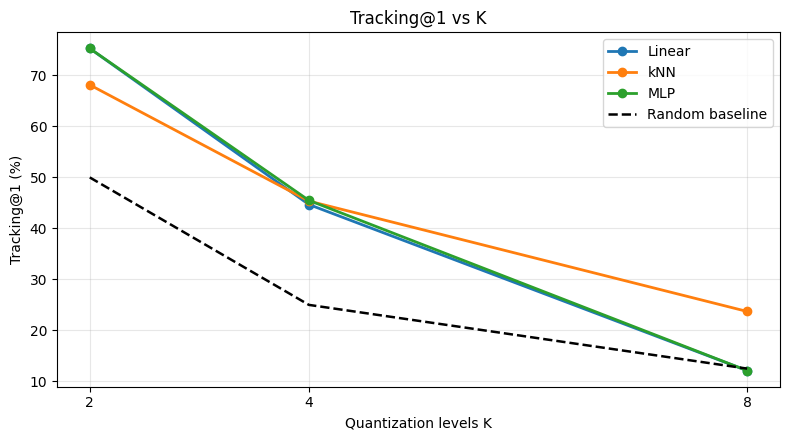

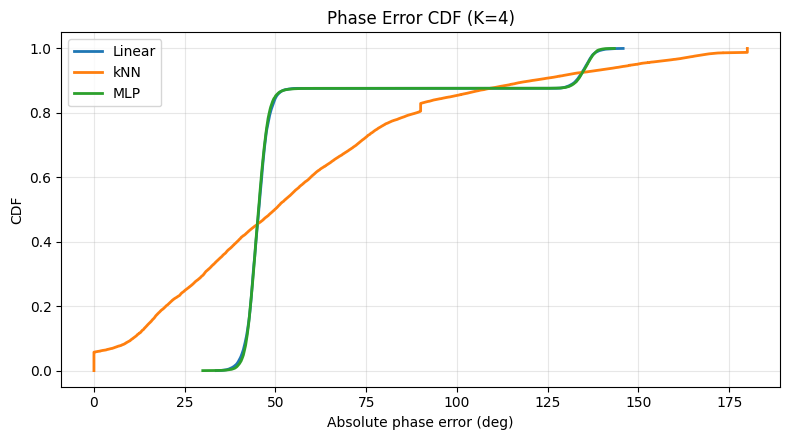

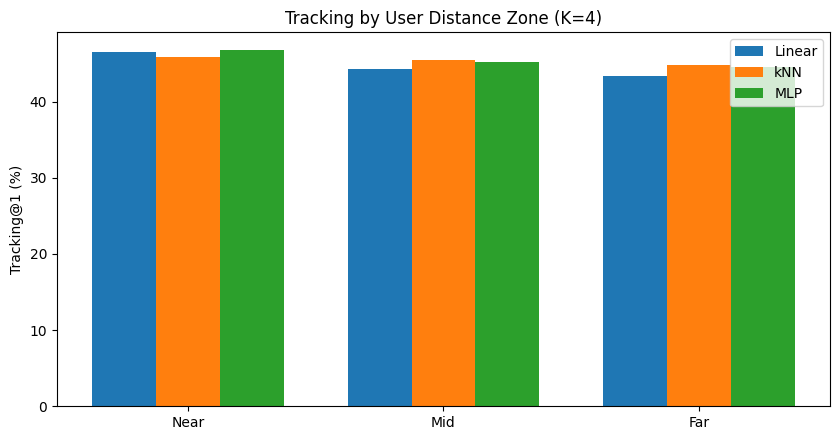

In [9]:
def evaluate_models_for_K(K_value, samples=2000):
    levels = np.linspace(0, 2 * np.pi, K_value, endpoint=False)
    Xk, yk = dataset(samples=samples, size=8, K=K_value)
    Xtr, Xte, ytr, yte = train_test_split(Xk, yk, train_ratio=0.8)

    models_local = [
        ("Linear", lambda: lg(Xtr, Xte, ytr, yte)),
        ("kNN", lambda: knn(Xtr, Xte, ytr, yte, k=5)),
        ("MLP", lambda: mlp(Xtr, Xte, ytr, yte, verbose=False)),
    ]

    out = {}
    y_true_idx = to_phase_idx(yte, levels)
    user_dist = np.linalg.norm(Xte, axis=1)

    q1, q2 = np.quantile(user_dist, [1/3, 2/3])
    zone_masks = {
        "near": user_dist <= q1,
        "mid": (user_dist > q1) & (user_dist <= q2),
        "far": user_dist > q2,
    }

    for model_name, run_model in models_local:
        t0 = time.time()
        y_pred, nmse_val = run_model()
        t_train = time.time() - t0

        y_pred_idx = to_phase_idx(y_pred, levels)
        trk1 = np.mean(y_pred_idx == y_true_idx)
        trk2 = topk_tracking(yte, y_pred, levels, k=min(2, K_value))
        phase_abs_err = np.abs(wrap_to_pi(y_pred - yte))
        mae_deg = np.degrees(np.mean(phase_abs_err))

        zone_tracking = {}
        for zone_name, mask in zone_masks.items():
            zone_tracking[zone_name] = np.mean(y_pred_idx[mask] == y_true_idx[mask])

        out[model_name] = {
            "nmse": nmse_val,
            "training_time": t_train,
            "tracking_at1": trk1,
            "tracking_at2": trk2,
            "phase_mae_deg": mae_deg,
            "phase_abs_err_flat": np.degrees(phase_abs_err).ravel(),
            "zone_tracking": zone_tracking,
        }

    return out


K_list = [2, 4, 8]
results_by_K = {Kval: evaluate_models_for_K(Kval, samples=2000) for Kval in K_list}
model_names = ["Linear", "kNN", "MLP"]

# Print compact table
for Kval in K_list:
    print(f"\n===== K = {Kval} =====")
    print(f"Random baseline Tracking@1: {100.0 / Kval:.2f}%")
    for m in model_names:
        r = results_by_K[Kval][m]
        z = r["zone_tracking"]
        print(
            f"{m:>6} | NMSE: {r['nmse']:.4f} | T: {r['training_time']:.3f}s "
            f"| Trk@1: {r['tracking_at1']*100:.2f}% | Trk@2: {r['tracking_at2']*100:.2f}% "
            f"| MAE: {r['phase_mae_deg']:.2f}deg | Zones N/M/F: "
            f"{z['near']*100:.1f}/{z['mid']*100:.1f}/{z['far']*100:.1f}%"
        )

# Plot A: Tracking@1 vs K + baseline
fig, ax = plt.subplots(figsize=(8, 4.5))
for m in model_names:
    y_vals = [results_by_K[Kval][m]["tracking_at1"] * 100 for Kval in K_list]
    ax.plot(K_list, y_vals, marker="o", linewidth=2, label=m)

baseline_vals = [100.0 / Kval for Kval in K_list]
ax.plot(K_list, baseline_vals, "k--", linewidth=1.8, label="Random baseline")
ax.set_xlabel("Quantization levels K")
ax.set_ylabel("Tracking@1 (%)")
ax.set_title("Tracking@1 vs K")
ax.set_xticks(K_list)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot B: CDF of phase error for K=4
K_ref = 4
fig, ax = plt.subplots(figsize=(8, 4.5))
for m in model_names:
    err = np.sort(results_by_K[K_ref][m]["phase_abs_err_flat"])
    cdf = np.linspace(0, 1, len(err), endpoint=False)
    ax.plot(err, cdf, linewidth=2, label=m)

ax.set_xlabel("Absolute phase error (deg)")
ax.set_ylabel("CDF")
ax.set_title("Phase Error CDF (K=4)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot C: Zone tracking for K=4
zones = ["near", "mid", "far"]
x = np.arange(len(zones))
width = 0.25
fig, ax = plt.subplots(figsize=(8.5, 4.5))

for i, m in enumerate(model_names):
    vals = [results_by_K[K_ref][m]["zone_tracking"][z] * 100 for z in zones]
    ax.bar(x + (i - 1) * width, vals, width=width, label=m)

ax.set_xticks(x)
ax.set_xticklabels([z.capitalize() for z in zones])
ax.set_ylabel("Tracking@1 (%)")
ax.set_title("Tracking by User Distance Zone (K=4)")
ax.legend()
plt.tight_layout()
plt.show()

## Results Discussion
The comparative analysis reveals a fundamental trade-off between prediction accuracy and computational complexity across the evaluated methods.

For $K=4$, all models surpass the random baseline of 25\% in Tracking@1 metric, demonstrating their ability to learn a meaningful mapping from UE position to IRS phase profiles. 
Linear regression and MLP exhibit comparable performance in both NMSE and phase error metrics, whereas k-NN proves less competitive in NMSE but maintains robustness in discrete tracking measures.

The Tracking@1 performance degrades systematically as quantization resolution increases from $K=2$ to $K=8$. 
This trend aligns with theoretical expectations, as finer phase quantization elevates the classification task difficulty. 
Consequently, Tracking@1 must be contextualized against the random baseline $1/K$: the observed 40--45\% accuracy at $K=4$ substantially exceeds chance performance, while values approaching 12.5\% at $K=8$ indicate near-random behavior for certain models.

The Tracking@2 metric provides complementary insight, revealing that even moderate Tracking@1 scores mask substantial nearest-neighbor accuracy. 
This suggests that prediction errors predominantly comprise small local deviations rather than gross phase misassignments.

The phase error CDF further validates this interpretation. 
A steeper, left-shifted CDF, characteristic of Linear regression and MLP, indicates error concentration within a narrower angular range and enhanced prediction stability. 
Conversely, k-NN displays a broader error distribution, reflecting greater variability.

Zone-based analysis (near/mid/far-field) reveals no pronounced spatial performance degradation, attributable to the spatial homogeneity of the synthetic dataset. 
While this facilitates equitable method comparison, it may obscure edge cases prevalent in realistic channel models.

From a practical deployment standpoint, linear regression offers the optimal speed-accuracy trade-off, MLP delivers comparable quality at elevated training cost, and k-NN emerges as preferable when nearest-level tracking robustness is prioritized at high quantization levels ($K$).